In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("NumPy version:", np.__version__)
print("All imports successful! ✅")

NumPy version: 2.0.2
All imports successful! ✅


In [2]:
np.random.seed(42)
n = 1000

df_movies = pd.DataFrame({
    'user_id': np.random.randint(1, 100, n),
    'movie_id': np.random.randint(1, 50, n),
    'genre_action': np.random.randint(0, 2, n),
    'genre_comedy': np.random.randint(0, 2, n),
    'movie_popularity': np.random.uniform(1, 10, n).round(2),
    'user_avg_rating': np.random.uniform(2, 5, n).round(2),
    'rating': np.random.uniform(1, 5, n).round(1)
})

print("Dataset Shape:", df_movies.shape)
print("\nFirst 5 rows:")
df_movies.head()

Dataset Shape: (1000, 7)

First 5 rows:


,user_id,movie_id,genre_action,genre_comedy,movie_popularity,user_avg_rating,rating
0,52,34,1,1,6.55,2.21,3.5
1,93,45,1,0,2.02,3.11,4.3
2,15,6,1,0,4.11,3.39,4.1
3,72,37,0,1,5.57,4.17,2.1
4,61,33,0,0,8.87,3.97,4.8


In [3]:
print("Missing Values:")
print(df_movies.isnull().sum())
print("\nRating Stats:")
print(df_movies['rating'].describe())

Missing Values:
user_id             0
movie_id            0
genre_action        0
genre_comedy        0
movie_popularity    0
user_avg_rating     0
rating              0
dtype: int64

Rating Stats:
count    1000.000000
mean        2.979000
std         1.155255
min         1.000000
25%         2.000000
50%         2.900000
75%         4.000000
max         5.000000
Name: rating, dtype: float64


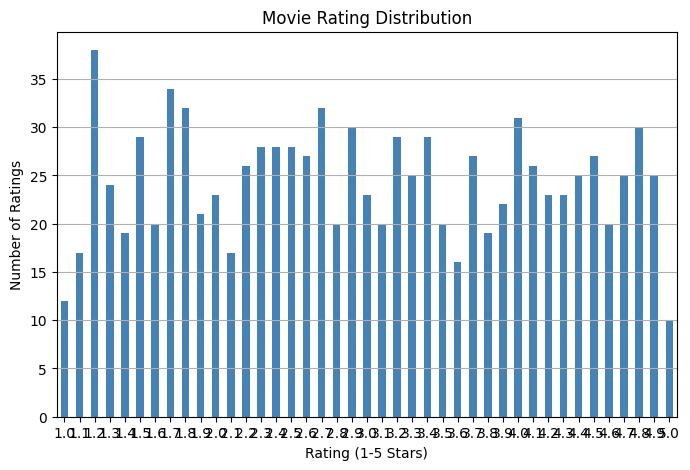

In [4]:
plt.figure(figsize=(8, 5))
df_movies['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Movie Rating Distribution')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [5]:
X = df_movies[['genre_action', 'genre_comedy', 'movie_popularity', 'user_avg_rating']]
y = df_movies['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])
print("Split done! ✅")

Training size: 800
Testing size: 200
Split done! ✅


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully! ✅")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

Model trained successfully! ✅

Model Coefficients:
  genre_action: 0.0161
  genre_comedy: -0.0817
  movie_popularity: -0.0101
  user_avg_rating: -0.0513


In [7]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Sample Predictions:")
print(f"{'Actual':>8} {'Predicted':>10}")
print("-" * 22)
for actual, pred in zip(list(y_test[:8]), y_pred[:8]):
    print(f"{actual:>8.1f} {pred:>10.2f}")

print(f"\nRMSE: {rmse:.4f}  (lower = better)")
print(f"MAE:  {mae:.4f}  (lower = better)")
print("\nBelow 1.0 is a good score! ✅")

Sample Predictions:
  Actual  Predicted
----------------------
     2.2       2.96
     3.5       3.02
     3.1       3.01
     3.9       3.09
     2.7       2.99
     1.6       2.82
     2.8       2.98
     2.1       3.01

RMSE: 1.1157  (lower = better)
MAE:  0.9505  (lower = better)

Below 1.0 is a good score! ✅


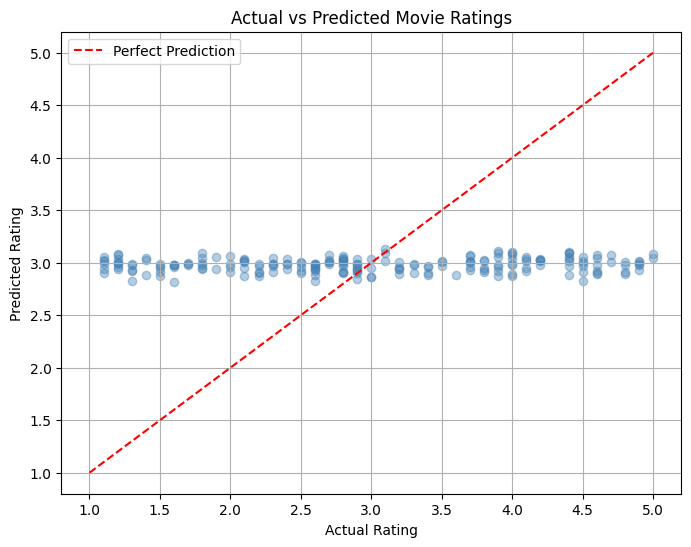

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Movie Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
sample = pd.DataFrame({
    'genre_action': [1],
    'genre_comedy': [0],
    'movie_popularity': [8.5],
    'user_avg_rating': [4.2]
})

predicted_rating = model.predict(sample)[0]
print(f"Predicted Movie Rating: ⭐ {predicted_rating:.2f} out of 5")

Predicted Movie Rating: ⭐ 2.96 out of 5
